<h1 style="color:#1f77b4;">SARIMAX BANXICO API - EXAM</h1>

 `Autoras:` 
 - Sarah Lucia Beltrán Gutiérrez
 - Aissa Berenice
 - Isabel Valladolid

 `Fecha:` 04/03/2026

 `Materia:` Non Linear Models

 `Profesor:` Pedro Martinez

---

<h2 style="color:#1f77b4;">Introduccion</h2>

En este proyecto se desarrolla un modelo `SARIMAX` para analizar y predecir el comportamiento del tipo de cambio **peso mexicano–dólar estadounidense** (FIX), utilizando datos oficiales obtenidos mediante la API del Banco de México. A partir de una serie temporal diaria, se busca evaluar la capacidad predictiva del modelo en el corto plazo, específicamente para el periodo del **5 al 13 de marzo de 2026**. El trabajo integra la descarga y procesamiento de datos, la justificación del modelo elegido y la evaluación de su desempeño mediante el error `MAPE`, con el fin de medir qué tan eficaz resulta `SARIMA` para anticipar movimientos del

---

In [14]:
# librerias
from dotenv import load_dotenv
import os
import requests
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import grangercausalitytests
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_ccf

In [15]:
# token desde .env
load_dotenv()
TOKEN = os.getenv("BANXICO_TOKEN")

In [16]:
# llamamos api :p
url = "https://www.banxico.org.mx/SieAPIRest/service/v1/series/SF43718/datos"
headers = {"Bmx-Token": TOKEN}

response = requests.get(url, headers=headers)
response.raise_for_status()
data = response.json()

In [17]:
# df
datos = data["bmx"]["series"][0]["datos"]
df = pd.DataFrame(datos)   
df.head()

,fecha,dato
0,12/11/1991,3.0735
1,13/11/1991,3.0712
2,14/11/1991,3.0718
3,15/11/1991,3.0684
4,18/11/1991,3.0673


In [18]:
df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True)
df["dato"] = pd.to_numeric(df["dato"], errors="coerce")

# fecha como indice
df.set_index("fecha", inplace=True)
df.sort_index(inplace=True)

<h2 style="color:#1f77b4;">Visualizacion</h2>

In [19]:
fig = px.line(
    df,
    x=df.index,
    y="dato",
    title="Serie de Tiempo: Tipo de Cambio FIX (MXN/USD)"
)

fig.update_layout(
    xaxis_title="Fecha",
    yaxis_title="Tipo de cambio FIX",
)

fig.show()

En la gráfica anterior se muestra la serie de tiempo de la base de datos de Banxico desde 1995 hasta 2026, a continuación se realizara el "corte" para que la prediccion no se ensucie con datos super viejos. Se tomara desde enero 2016.

In [20]:
df_cut = df.loc['2016-01-01':]

In [21]:
fig = px.line(
    df_cut,
    x=df_cut.index,
    y="dato",
    title="Serie de Tiempo: Tipo de Cambio FIX (MXN/USD) – Datos Recientes"
)

fig.update_layout(
    xaxis_title="Fecha",
    yaxis_title="Tipo de cambio FIX",
)

fig.show()

<h2 style="color:#1f77b4;">Análisis para el (p,d,q) y (P,D,Q,s)</h2> 

In [22]:
# Prueba de Dickey-Fuller Aumentada (ADF)
def run_adf(series, name):
    result = adfuller(series.dropna())
    print(f'--- Prueba ADF para: {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print("La serie es ESTACIONARIA (Podemos modelar)")
    else:
        print("La serie NO es estacionaria (Necesita más diferenciación)")

Resultados de Estacionariedad:
--- Prueba ADF para: Log Cambio (Sin diferenciar) ---
ADF Statistic: -2.7030
p-value: 0.0735
La serie NO es estacionaria (Necesita más diferenciación)


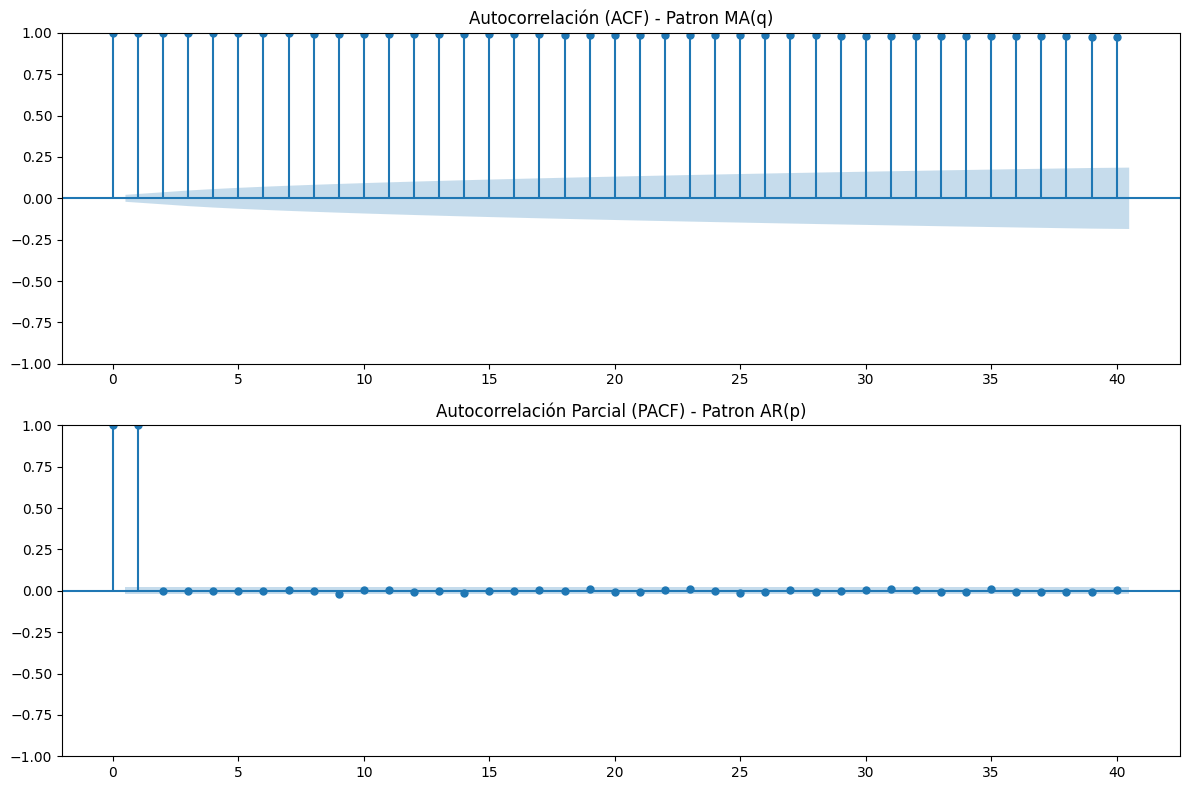

In [23]:
# Tranformamos pasajeros a log
df['Log_Cambio'] = np.log(df['dato'])


print("Resultados de Estacionariedad:")
run_adf(df['Log_Cambio'], "Log Cambio (Sin diferenciar)")

# Usamos la serie diferenciada porque es la que entra al modelo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['Log_Cambio'].dropna(), lags=40, ax=ax1, title="Autocorrelación (ACF) - Patron MA(q)")
plot_pacf(df['Log_Cambio'].dropna(), lags=40, ax=ax2, title="Autocorrelación Parcial (PACF) - Patron AR(p)")
plt.tight_layout()
plt.show()

Resultados de Estacionariedad:
--- Prueba ADF para: Log Log Cambio (Sin diferenciar) ---
ADF Statistic: -3.2794
p-value: 0.0158
La serie es ESTACIONARIA (Podemos modelar)


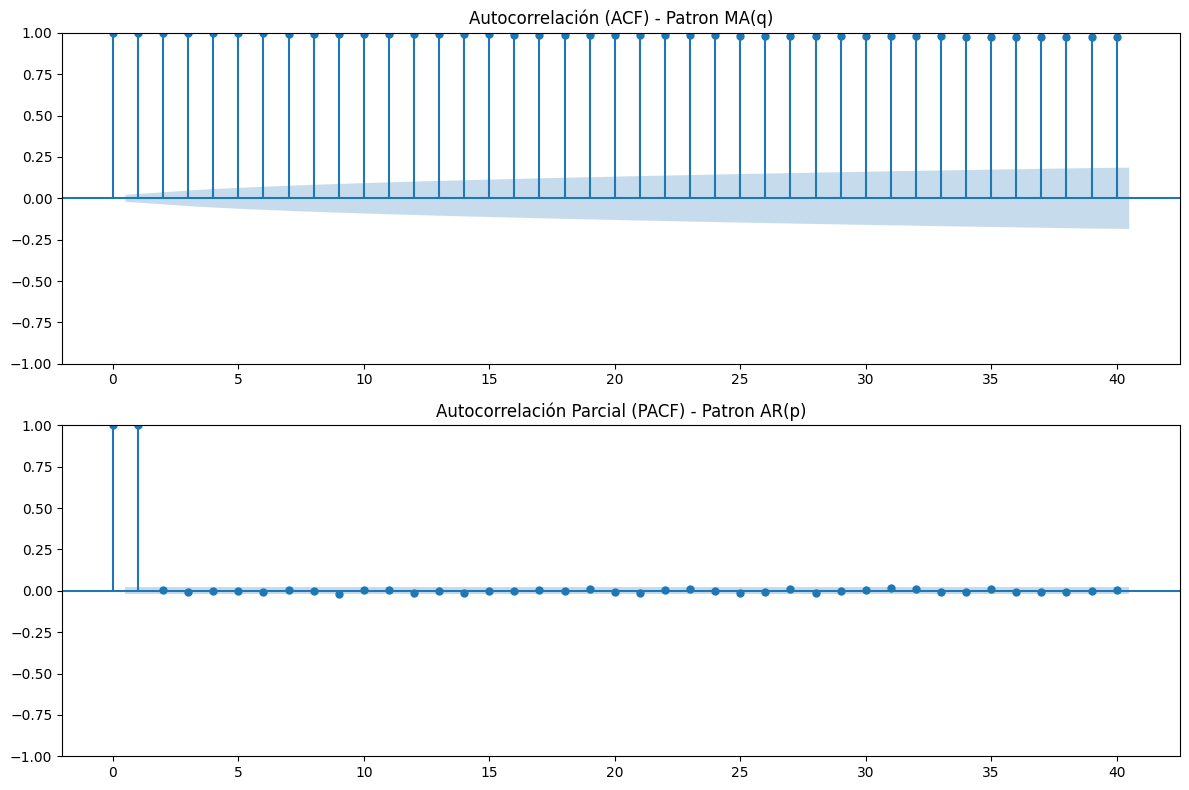

In [24]:
# Tranformamos pasajeros a log
df['Log_Log_Cambio'] = np.log(df['Log_Cambio'])


print("Resultados de Estacionariedad:")
run_adf(df['Log_Log_Cambio'], "Log Log Cambio (Sin diferenciar)")
# Usamos la serie diferenciada porque es la que entra al modelo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['Log_Log_Cambio'].dropna(), lags=40, ax=ax1, title="Autocorrelación (ACF) - Patron MA(q)")
plot_pacf(df['Log_Log_Cambio'].dropna(), lags=40, ax=ax2, title="Autocorrelación Parcial (PACF) - Patron AR(p)")
plt.tight_layout()
plt.show()

Resultados de Estacionariedad:
--- Prueba ADF para: Log Log Cambio (Diferencia Semanal) ---
ADF Statistic: -12.5826
p-value: 0.0000
La serie es ESTACIONARIA (Podemos modelar)


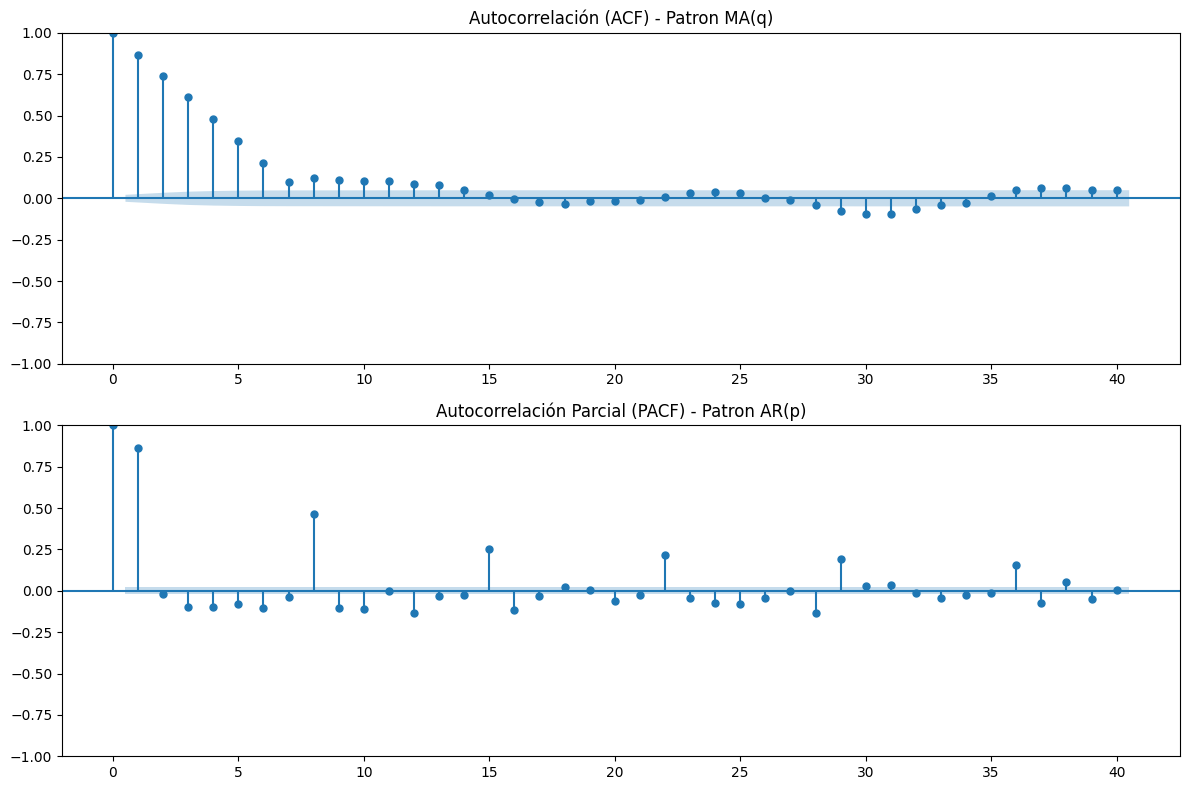

In [25]:
# Diferenciación Estacional (Lag 7 para datos diarios)
# Restamos a hoy el valor de hace una semana
df['Diff_7'] = df['Log_Log_Cambio'].diff(7).dropna() # calcular la diferencia del valor 7 (hoy menos lo que pasará en 7 días)

print("Resultados de Estacionariedad:")
run_adf(df['Diff_7'], "Log Log Cambio (Diferencia Semanal)")

# Gráficas ACF y PACF
# Esto nos ayuda a elegir p y q del modelo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
# Usamos la serie diferenciada porque es la que entra al modelo
plot_acf(df['Diff_7'].dropna(), lags=40, ax=ax1, title="Autocorrelación (ACF) - Patron MA(q)")
plot_pacf(df['Diff_7'].dropna(), lags=40, ax=ax2, title="Autocorrelación Parcial (PACF) - Patron AR(p)")
plt.tight_layout()
plt.show()